In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.svm import SVC 
from imblearn.over_sampling import SMOTE 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, LSTM, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Reshape
from tensorflow.keras.layers import GRU
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, MultiHeadAttention, LayerNormalization, Reshape, Flatten
from sklearn.metrics import accuracy_score, classification_report
import warnings

warnings.filterwarnings('ignore') 

In [3]:


# --------------------------------------------------------
# A. Data Loading and Initial Cleaning
# --------------------------------------------------------
# Load the dataset (assuming the path is correct as in your notebook)
data = pd.read_csv("C:/Users/Lenovo/Downloads/archive/healthcare-dataset-stroke-data.csv")
data.drop('id', axis=1, inplace=True)

# Handle the 'bmi' missing values by filling them with the median
data['bmi'].fillna(data['bmi'].median(), inplace=True)

# Remove the 'Other' gender row as it is a minimal outlier (only 1 entry)
data = data[data['gender'] != 'Other']

# --------------------------------------------------------
# B. Categorical Encoding (Label Encoding)
# --------------------------------------------------------
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
le = LabelEncoder()
for col in categorical_cols:
    data[col] = le.fit_transform(data[col])

# Separate features (X) and target (y)
X = data.drop('stroke', axis=1).values
y = data['stroke'].values

print("Data Preprocessing Complete.")
print(f"Features shape: {X.shape}, Target shape: {y.shape}")
print(f"Stroke distribution (0: No, 1: Yes): {np.unique(y, return_counts=True)}")

Data Preprocessing Complete.
Features shape: (5109, 10), Target shape: (5109,)
Stroke distribution (0: No, 1: Yes): (array([0, 1], dtype=int64), array([4860,  249], dtype=int64))


In [4]:
# --------------------------------------------------------
# A. Train/Validation/Test Split
# --------------------------------------------------------
# 1. Split into Train (70%) and Temporary (30%)
X_train_full, X_temp, y_train_full, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 2. Split Temporary into Validation (15%) and Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# --------------------------------------------------------
# B. Feature Scaling (StandardScaler)
# --------------------------------------------------------
scaler = StandardScaler()
# Fit scaler only on the training data and transform all splits
X_train_full = scaler.fit_transform(X_train_full)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# --------------------------------------------------------
# C. SMOTE Over-sampling on Training Data
# --------------------------------------------------------
smote = SMOTE(random_state=42)
# Apply SMOTE only to the full training set (NOT validation or test)
X_train, y_train = smote.fit_resample(X_train_full, y_train_full)

print(f"Original Training Set Shape (before SMOTE): {X_train_full.shape}")
print(f"Balanced Training Set Shape (after SMOTE): {X_train.shape}")
print(f"Test Set Shape: {X_test.shape}")
print("-" * 50)

Original Training Set Shape (before SMOTE): (3576, 10)
Balanced Training Set Shape (after SMOTE): (6804, 10)
Test Set Shape: (767, 10)
--------------------------------------------------


In [5]:
# --------------------------------------------------------
# A. ANN Model Definition
# --------------------------------------------------------
print("Training ANN...")
ann = Sequential([
    # Input layer and first hidden layer
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    # Output layer: 1 neuron with sigmoid for binary classification
    Dense(1, activation='sigmoid') 
])

# Use binary_crossentropy for sigmoid output with unencoded labels
ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# --------------------------------------------------------
# B. ANN Training and Evaluation
# --------------------------------------------------------
history_ann = ann.fit(
    X_train, y_train, 
    epochs=50, 
    batch_size=32, 
    validation_data=(X_val, y_val), # Use unencoded validation labels
    verbose=1
)

# Predict probabilities and convert to binary classes (0 or 1)
ann_pred_prob = ann.predict(X_test, verbose=0)
ann_pred = (ann_pred_prob > 0.5).astype("int32")
ann_acc = accuracy_score(y_test, ann_pred)

print(f"✅ ANN Accuracy: {ann_acc*100:.2f}%")
print("ANN Classification Report:\n", classification_report(y_test, ann_pred, zero_division=0))

Training ANN...
Epoch 1/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7631 - loss: 0.4979 - val_accuracy: 0.7585 - val_loss: 0.4330
Epoch 2/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8057 - loss: 0.4294 - val_accuracy: 0.7363 - val_loss: 0.4803
Epoch 3/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8208 - loss: 0.4092 - val_accuracy: 0.7507 - val_loss: 0.4341
Epoch 4/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8251 - loss: 0.3914 - val_accuracy: 0.7715 - val_loss: 0.4178
Epoch 5/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8300 - loss: 0.3824 - val_accuracy: 0.7702 - val_loss: 0.4217
Epoch 6/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8404 - loss: 0.3683 - val_accuracy: 0.8042 - val_loss: 0.3781
Epoch 7/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8401 - loss: 0.3591 - val_accuracy: 0.7937 - val_loss: 0.3903
Epoch 8/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8495 - loss: 0.3453 - 

In [6]:
# --------------------------------------------------------
# A. GRU Model Definition
# --------------------------------------------------------
print("Training GRU...")
gru = Sequential([
    Reshape((X_train.shape[1], 1), input_shape=(X_train.shape[1],)),
    GRU(64, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

gru.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# --------------------------------------------------------
# B. GRU Training and Evaluation
# --------------------------------------------------------
history_gru = gru.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

gru_pred_prob = gru.predict(X_test, verbose=0)
gru_pred = (gru_pred_prob > 0.5).astype("int32")
gru_acc = accuracy_score(y_test, gru_pred)

print(f"✅ GRU Accuracy: {gru_acc*100:.2f}%")
print("GRU Classification Report:\n", classification_report(y_test, gru_pred, zero_division=0))


Training GRU...
Epoch 1/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.6700 - loss: 0.5981 - val_accuracy: 0.6945 - val_loss: 0.5061
Epoch 2/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6971 - loss: 0.5620 - val_accuracy: 0.7010 - val_loss: 0.5045
Epoch 3/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7091 - loss: 0.5522 - val_accuracy: 0.6723 - val_loss: 0.5231
Epoch 4/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7385 - loss: 0.5230 - val_accuracy: 0.6736 - val_loss: 0.4912
Epoch 5/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7690 - loss: 0.4931 - val_accuracy: 0.6828 - val_loss: 0.4858
Epoch 6/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7806 - loss: 0.4691 - val_accuracy: 0.6802 - val_loss: 0.4951
Epoch 7/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7835 - loss: 0.4603 - val_accuracy: 0.6358 - val_loss: 0.5260
Epoch 8/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7898 - loss: 0.4506 - 

In [7]:
# --------------------------------------------------------
# A. Prepare Data for CNN-LSTM (3D and One-Hot Encoding)
# --------------------------------------------------------
# Reshape data from 2D (samples, features) to 3D (samples, features, 1)
X_train_dl = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val_dl = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
X_test_dl = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Convert y labels to categorical (one-hot encoding) for Softmax
y_train_dl = to_categorical(y_train)
y_val_dl = to_categorical(y_val)
y_test_dl = to_categorical(y_test)

# --------------------------------------------------------
# B. CNN-LSTM Model Definition
# --------------------------------------------------------
print("Training CNN-LSTM...")
cnn_lstm = Sequential([
    # Conv1D extracts spatial features from the 1D input sequence
    Conv1D(64, 3, activation='relu', input_shape=(X_train_dl.shape[1], 1)),
    MaxPooling1D(2),
    Dropout(0.3),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(2, activation='softmax') 
])

# Use categorical_crossentropy with one-hot encoded labels
cnn_lstm.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# --------------------------------------------------------
# C. CNN-LSTM Training and Evaluation
# --------------------------------------------------------
history_cnn_lstm = cnn_lstm.fit(
    X_train_dl, y_train_dl, 
    epochs=50, 
    batch_size=32, 
    validation_data=(X_val_dl, y_val_dl), 
    verbose=1
)

# Predict probabilities and convert to class labels (index of the max probability)
cnn_lstm_pred_prob = cnn_lstm.predict(X_test_dl, verbose=0)
cnn_lstm_pred = np.argmax(cnn_lstm_pred_prob, axis=1)
cnn_lstm_acc = accuracy_score(y_test, cnn_lstm_pred)

print(f"✅ CNN-LSTM Accuracy: {cnn_lstm_acc*100:.2f}%")
print("CNN-LSTM Classification Report:\n", classification_report(y_test, cnn_lstm_pred, zero_division=0))



Training CNN-LSTM...
Epoch 1/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7277 - loss: 0.5396 - val_accuracy: 0.7010 - val_loss: 0.4613
Epoch 2/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7745 - loss: 0.4748 - val_accuracy: 0.6658 - val_loss: 0.5142
Epoch 3/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7769 - loss: 0.4654 - val_accuracy: 0.6997 - val_loss: 0.4462
Epoch 4/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7829 - loss: 0.4540 - val_accuracy: 0.6997 - val_loss: 0.4460
Epoch 5/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7901 - loss: 0.4461 - val_accuracy: 0.7298 - val_loss: 0.4236
Epoch 6/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7950 - loss: 0.4398 - val_accuracy: 0.7154 - val_loss: 0.4380
Epoch 7/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8035 - loss: 0.4332 - val_accuracy: 0.7311 - val_loss: 0.4482
Epoch 8/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8032 - loss: 0.42

In [8]:

# --------------------------------------------------------
# B. Model Definition
# --------------------------------------------------------
print("Training Transformer-inspired Model...")

# Input layer
input_layer = Input(shape=(X_train.shape[1],))

# Project input to higher dimension and reshape for attention
x = Dense(128, activation='relu')(input_layer)
x = Reshape((1, 128))(x)  # Reshape to (batch, sequence, features)

# Multi-head attention
attn_output = MultiHeadAttention(num_heads=2, key_dim=64)(x, x)
x = LayerNormalization()(attn_output)

# Flatten and continue with dense layers
x = Flatten()(x)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
output_layer = Dense(1, activation='sigmoid')(x)

# Build and compile model
transformer_model = Model(inputs=input_layer, outputs=output_layer)
transformer_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# --------------------------------------------------------
# C. Training and Evaluation
# --------------------------------------------------------
history_transformer = transformer_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

# Predict and evaluate
transformer_pred_prob = transformer_model.predict(X_test, verbose=0)
transformer_pred = (transformer_pred_prob > 0.5).astype("int32")
transformer_acc = accuracy_score(y_test, transformer_pred)

print(f"✅ Transformer Accuracy: {transformer_acc*100:.2f}%")
print("Transformer Classification Report:\n", classification_report(y_test, transformer_pred, zero_division=0))


Training Transformer-inspired Model...
Epoch 1/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7975 - loss: 0.4443 - val_accuracy: 0.7219 - val_loss: 0.4487
Epoch 2/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8317 - loss: 0.3844 - val_accuracy: 0.7898 - val_loss: 0.4128
Epoch 3/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8508 - loss: 0.3437 - val_accuracy: 0.8251 - val_loss: 0.3481
Epoch 4/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8620 - loss: 0.3231 - val_accuracy: 0.8055 - val_loss: 0.4057
Epoch 5/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8667 - loss: 0.3057 - val_accuracy: 0.7833 - val_loss: 0.4678
Epoch 6/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8787 - loss: 0.2910 - val_accuracy: 0.8277 - val_loss: 0.3994
Epoch 7/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8840 - loss: 0.2734 - val_accuracy: 0.8029 - val_loss: 0.3822
Epoch 8/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0

In [9]:
# MODEL COMPARISON

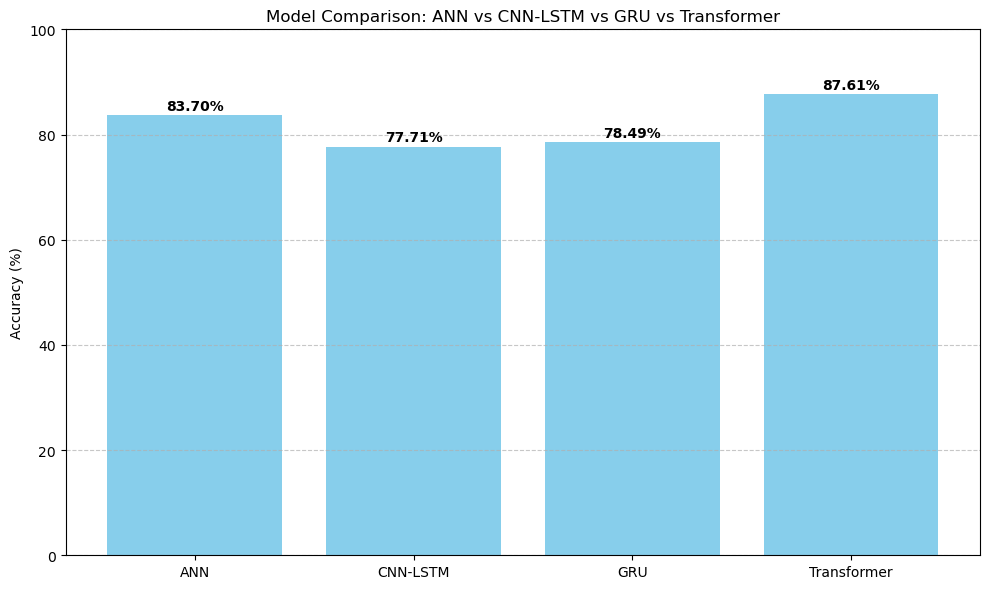

In [10]:
import matplotlib.pyplot as plt

# Define model accuracies (already in %)
model_scores = {
    'ANN': 83.70,
    'CNN-LSTM': 77.71,
    'GRU': 78.49,
    'Transformer': 87.61
}

# Plotting function
def plot_model_comparison(scores, title):
    plt.figure(figsize=(10, 6))
    plt.bar(scores.keys(), list(scores.values()), color='skyblue')
    plt.ylabel('Accuracy (%)')
    plt.title(title)
    plt.ylim(0, 100)
    for i, v in enumerate(scores.values()):
        plt.text(i, v + 1, f"{v:.2f}%", ha='center', fontweight='bold')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Call once
plot_model_comparison(model_scores, 'Model Comparison: ANN vs CNN-LSTM vs GRU vs Transformer')

THE BEST MODEL AMONG ALL THE COMPARSION IS TRANSFORMER EITH ACCURACY OF 87.61
📊 ANN Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.88      0.92       729
           1       0.10      0.26      0.14        38

    accuracy                           0.85       767
   macro avg       0.53      0.57      0.53       767
weighted avg       0.92      0.85      0.88       767



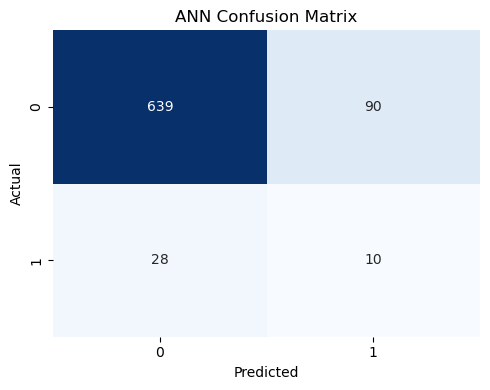

CNN-LSTM Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.80      0.87       729
           1       0.10      0.45      0.17        38

    accuracy                           0.78       767
   macro avg       0.53      0.62      0.52       767
weighted avg       0.92      0.78      0.84       767



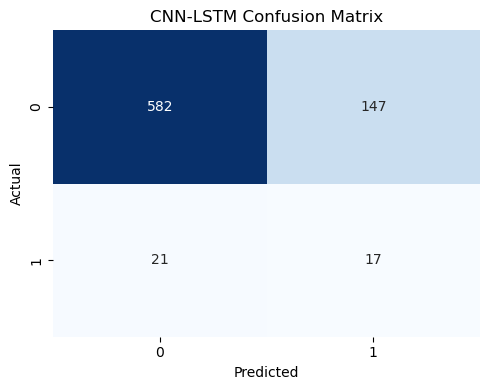

📊 GRU Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.83      0.89       729
           1       0.13      0.50      0.21        38

    accuracy                           0.81       767
   macro avg       0.55      0.66      0.55       767
weighted avg       0.93      0.81      0.86       767



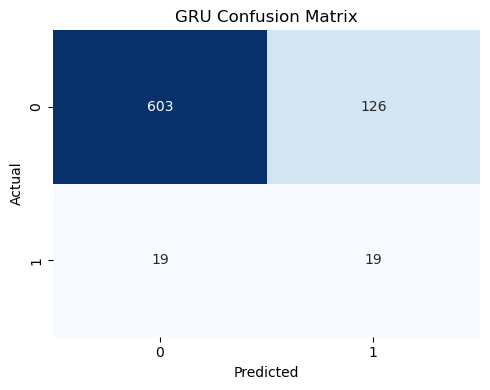

📊 Transformer Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.91      0.93       729
           1       0.12      0.24      0.16        38

    accuracy                           0.87       767
   macro avg       0.54      0.57      0.54       767
weighted avg       0.92      0.87      0.89       767



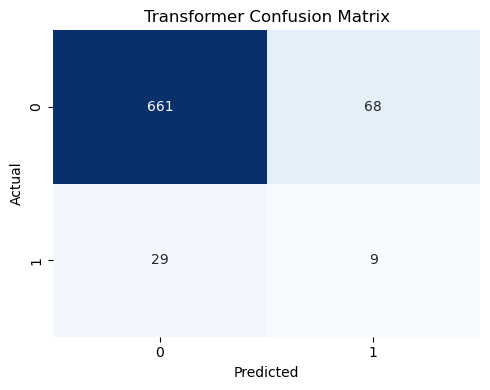

In [11]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# --------------------------------------------------------
# A. Utility Function to Plot Confusion Matrix
# --------------------------------------------------------
def plot_conf_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()


print("THE BEST MODEL AMONG ALL THE COMPARSION IS TRANSFORMER EITH ACCURACY OF 87.61")

# --------------------------------------------------------
# B. ANN
# --------------------------------------------------------
print("📊 ANN Classification Report:")
print(classification_report(y_test, ann_pred, zero_division=0))
plot_conf_matrix(y_test, ann_pred, "ANN")

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute confusion matrix
print("CNN-LSTM Classification Report:\n", classification_report(y_test, cnn_lstm_pred, zero_division=0))
cm = confusion_matrix(y_test, cnn_lstm_pred)

# Plot confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('CNN-LSTM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# --------------------------------------------------------
# D. GRU
# --------------------------------------------------------
print("📊 GRU Classification Report:")
print(classification_report(y_test, gru_pred, zero_division=0))
plot_conf_matrix(y_test, gru_pred, "GRU")

# --------------------------------------------------------
# E. Transformer
# --------------------------------------------------------
print("📊 Transformer Classification Report:")
print(classification_report(y_test, transformer_pred, zero_division=0))
plot_conf_matrix(y_test, transformer_pred, "Transformer")